In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../exoplanet_data.csv", comment="#")

In [11]:
print(df.shape) #567 by 92
print(df.columns)
# 5 columns that i have no idea what they are are 'pl_bmasselim', 'pl_bmassj''pl_eqtlim', 'ttv_flag', 'st_refname',

(567, 92)
Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 's

In [12]:
# Table Label: Planet Name
# Database Column Name: pl_name
# Meaning: The official name of the exoplanet. Every planet outside our Solar System has an ID or name.

# Table Label: Host Name
# Database Column Name: hostname
# Meaning: The name of the star that the exoplanet orbits.

# Table Label: Discovery Method
# Database Column Name: discoverymethod
# Meaning: How the planet was discovered.

# Table Label: Spectral Type
# Database Column Name: st_spectype
# Meaning: The class of the host star based on temperature/color (like O, B, A, F, G, K, M).
# Hotter stars are earlier letters (O hot/blue), cooler stars are later (M cool/red).

# Table Label: Equilibrium Temperature [K]
# Database Column Name: pl_eqt
# Meaning: Estimated temperature of the planet in Kelvin (K). 
# Higher values mean hotter planets; depends on distance from star and star's brightness.

# Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]
# Database Column Name: pl_bmassj
# Meaning: Mass of the exoplanet measured in Jupiter masses. Bigger value = more massive planet.


In [13]:
small = df[[
    "pl_name",
    "hostname",
    "discoverymethod",
    "st_spectype",
    "pl_eqt",
    "pl_bmassj"
]]
small = small.dropna()

In [14]:
print(small.shape)
print(small.head())
print(small.tail())
print(small.columns)

(67, 6)
    pl_name hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
2  DMPP-1 b   DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3  DMPP-1 c   DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4  DMPP-1 d   DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
5  DMPP-1 e   DMPP-1  Radial Velocity        F8 V  1314.0   0.012994
6  DMPP-2 b   DMPP-2  Radial Velocity        F5 V  1000.0   0.437000
         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
545   WASP-185 b   WASP-185          Transit        G0 V  1160.0      0.980
548   WASP-190 b   WASP-190          Transit     F6 IV-V  1500.0      1.000
553   WASP-192 b   WASP-192          Transit        G0 V  1620.0      2.300
556       XO-7 b       XO-7          Transit        G0 V  1743.0      0.709
566  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0      6.310
Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [15]:
print(small["discoverymethod"].unique())

['Radial Velocity' 'Transit' 'Imaging']


In [17]:
print(small["discoverymethod"].value_counts())

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


In [18]:
# There are 52 planets discovered by Transit, 13 by Radial Velocity, and 2 by Imaging
# The most common method in this dataset is Transit
# The least common method in this dataset is Imaging

# Transit: Planet crosses in front of its star, causing a small dip in brightness.
# Radial Velocity: Planet's gravity makes the star wobble and we detect tiny shifts in starlight.
# Imaging: Telescope directly captures the planet; works for big planets far from their star.


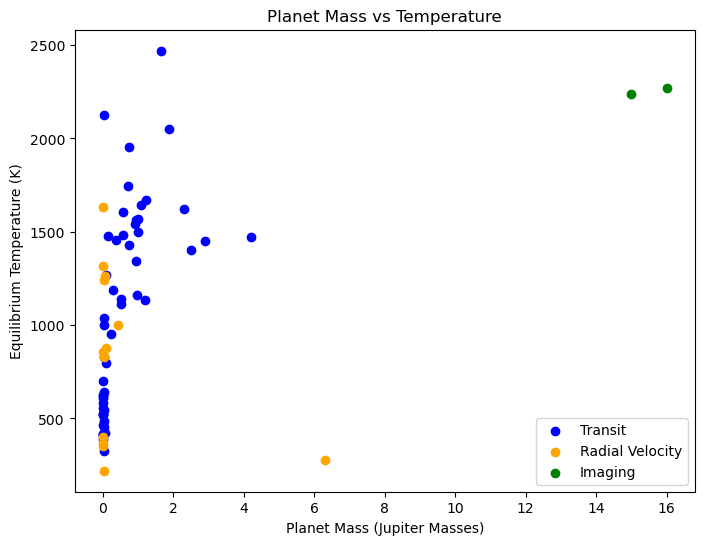

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(small[small["discoverymethod"]=="Transit"]["pl_bmassj"],
            small[small["discoverymethod"]=="Transit"]["pl_eqt"],
            color="blue", label="Transit")

plt.scatter(small[small["discoverymethod"]=="Radial Velocity"]["pl_bmassj"],
            small[small["discoverymethod"]=="Radial Velocity"]["pl_eqt"],
            color="orange", label="Radial Velocity")

plt.scatter(small[small["discoverymethod"]=="Imaging"]["pl_bmassj"],
            small[small["discoverymethod"]=="Imaging"]["pl_eqt"],
            color="green", label="Imaging")

plt.title("Planet Mass vs Temperature")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend()
plt.show()


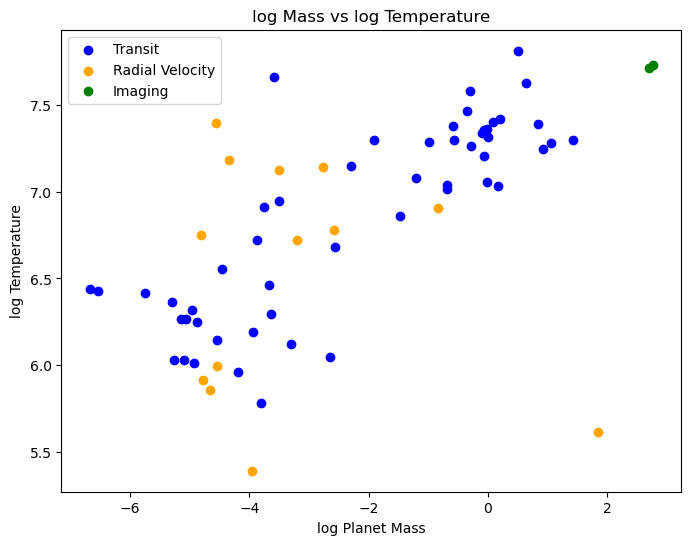

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(np.log(small[small["discoverymethod"]=="Transit"]["pl_bmassj"]),
            np.log(small[small["discoverymethod"]=="Transit"]["pl_eqt"]),
            color="blue", label="Transit")

plt.scatter(np.log(small[small["discoverymethod"]=="Radial Velocity"]["pl_bmassj"]),
            np.log(small[small["discoverymethod"]=="Radial Velocity"]["pl_eqt"]),
            color="orange", label="Radial Velocity")

plt.scatter(np.log(small[small["discoverymethod"]=="Imaging"]["pl_bmassj"]),
            np.log(small[small["discoverymethod"]=="Imaging"]["pl_eqt"]),
            color="green", label="Imaging")

plt.title("log Mass vs log Temperature")
plt.xlabel("log Planet Mass")
plt.ylabel("log Temperature")
plt.legend()
plt.show()


In [23]:
# Imaging planets are usually more massive.


In [24]:
big = small[small["pl_bmassj"] > 5]
coldest = big.loc[big["pl_eqt"].idxmin()]
coldest

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 566, dtype: object

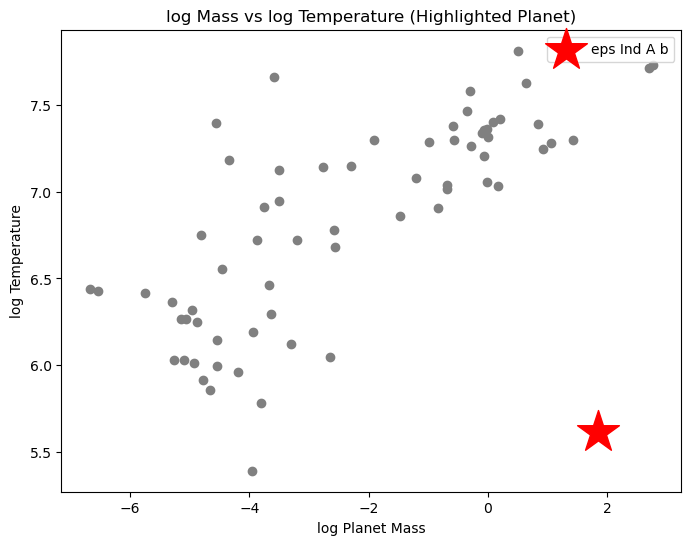

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(np.log(small["pl_bmassj"]), np.log(small["pl_eqt"]), color="gray")

plt.scatter(np.log(coldest["pl_bmassj"]), np.log(coldest["pl_eqt"]), color="red", s=1000, marker="*", label=coldest["pl_name"])

plt.title("log Mass vs log Temperature (Highlighted Planet)")
plt.xlabel("log Planet Mass")
plt.ylabel("log Temperature")
plt.legend()
plt.show()


In [ ]:
# Title: A temperate super-Jupiter imaged with JWST in the mid-infrared.

# Abstract summary: JWST directly imaged a very cold giant planet, about 275 K, orbiting a nearby star.

# Match the exoplanet? Yes, it matches the planet found in the data.

# What’s special? It’s the coldest directly-imaged giant planet ever found.

# Mass & temperature check: Paper says ~6–9 Jupiter masses and ~275 K; if my numbers differ, 
# the paper’s values are the correct ones.
